# Visualización de Datos Climáticos de Bogotá
## Fuente: Open-Meteo Historical Weather API
### Período: 2024-01-01 al 2024-12-31

In [1]:
#Celda 1 - librerias necesarias para la visualiacion
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
#celda 2 - cargar el csv procesado
ruta_csv = os.path.join("..", "data", "processed", "clima_bogota_limpio.csv")

df = pd.read_csv(ruta_csv, index_col="time", parse_dates=True)

print(df.shape)
df.head()

(8784, 4)


,temperature_2m,precipitation,windspeed_10m,relativehumidity_2m
time,,,,
2024-01-01 00:00:00,13.1,1.4,1.1,99
2024-01-01 01:00:00,12.9,0.0,1.1,100
2024-01-01 02:00:00,12.2,0.0,0.7,100
2024-01-01 03:00:00,10.2,0.0,2.4,100
2024-01-01 04:00:00,10.6,0.0,3.0,100


In [3]:
#celda 3 - agregar datos hprarios a nivel mensual 
df_mensual = df.resample("ME").agg({
    "temperature_2m": "mean",
    "precipitation":  "sum",
    "windspeed_10m":      "mean",
    "relativehumidity_2m": "mean"
})

print(df_mensual)

            temperature_2m  precipitation  windspeed_10m  relativehumidity_2m
time                                                                         
2024-01-31       14.117339           20.7       5.657661            74.384409
2024-02-29       14.792241           74.6       4.925000            79.316092
2024-03-31       15.101613           79.7       5.556586            77.404570
2024-04-30       14.606528          194.9       4.835139            80.052778
2024-05-31       14.519355          223.1       4.832392            83.920699
2024-06-30       13.609444          151.3       4.778750            84.245833
2024-07-31       13.326882           65.9       6.770833            81.216398
2024-08-31       13.073387           32.8       6.990995            77.470430
2024-09-30       14.026111           34.7       7.255139            74.947222
2024-10-31       13.668952          116.5       5.085215            80.384409
2024-11-30       13.480833          255.8       3.692083        

In [4]:
#celda - 4 agrega datos horarios a nivel mensual
df_mensual = df.resample("ME").agg({
    "temperature_2m": "mean",
    "precipitation": "sum",
    "windspeed_10m": "mean",
    "relativehumidity_2m": "mean"
})

print(df_mensual)

            temperature_2m  precipitation  windspeed_10m  relativehumidity_2m
time                                                                         
2024-01-31       14.117339           20.7       5.657661            74.384409
2024-02-29       14.792241           74.6       4.925000            79.316092
2024-03-31       15.101613           79.7       5.556586            77.404570
2024-04-30       14.606528          194.9       4.835139            80.052778
2024-05-31       14.519355          223.1       4.832392            83.920699
2024-06-30       13.609444          151.3       4.778750            84.245833
2024-07-31       13.326882           65.9       6.770833            81.216398
2024-08-31       13.073387           32.8       6.990995            77.470430
2024-09-30       14.026111           34.7       7.255139            74.947222
2024-10-31       13.668952          116.5       5.085215            80.384409
2024-11-30       13.480833          255.8       3.692083        

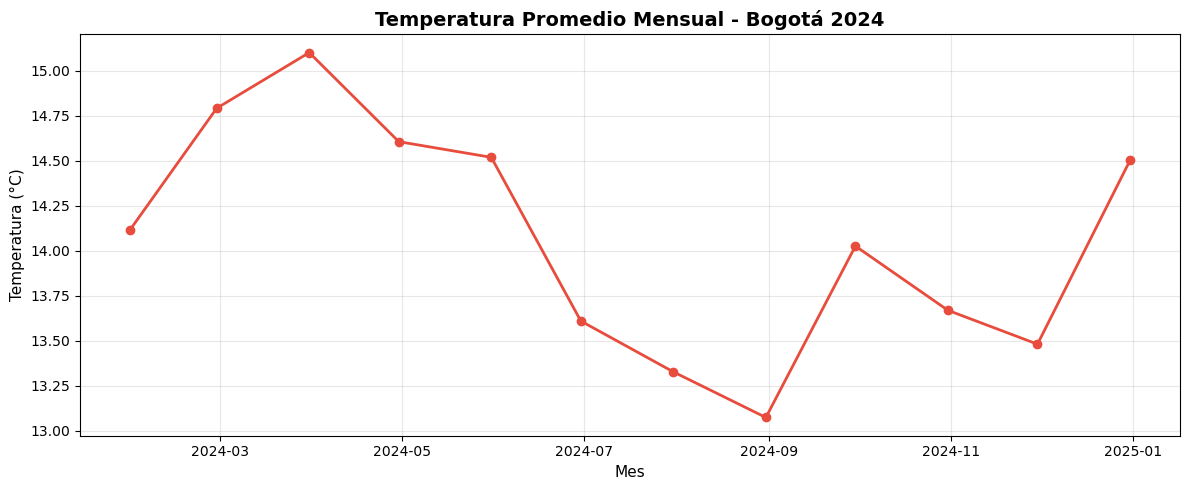

In [5]:
#celda 5 - grafica 1: Temperatura promedio mensual
fig, ax = plt.subplots(figsize=(12,5))

ax.plot(df_mensual.index, df_mensual["temperature_2m"],
        marker="o", color="#E74C3C", linewidth=2)

ax.set_title("Temperatura Promedio Mensual - Bogotá 2024", fontsize=14, fontweight="bold")
ax.set_xlabel("Mes", fontsize=11)
ax.set_ylabel("Temperatura (°C)", fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

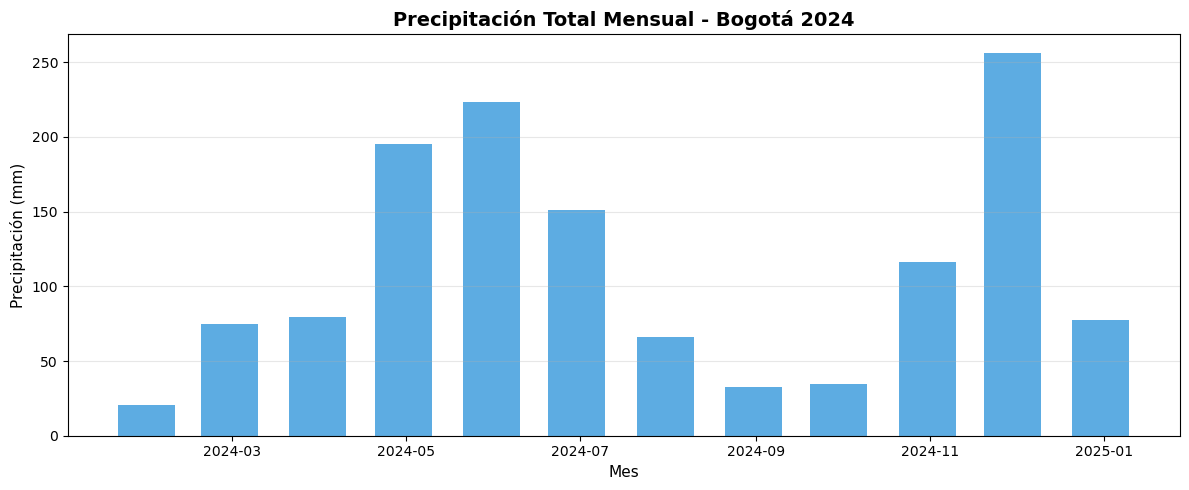

In [6]:
#celda 6 - Grafica 2:  prcipitacion total mensual
fig, ax = plt.subplots(figsize=(12,5))

ax.bar(df_mensual.index, df_mensual["precipitation"],
        width=20, color="#3498DB", alpha=0.8)

ax.set_title("Precipitación Total Mensual - Bogotá 2024", fontsize=14, fontweight="bold")
ax.set_xlabel("Mes", fontsize=11)
ax.set_ylabel("Precipitación (mm)", fontsize=11)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()


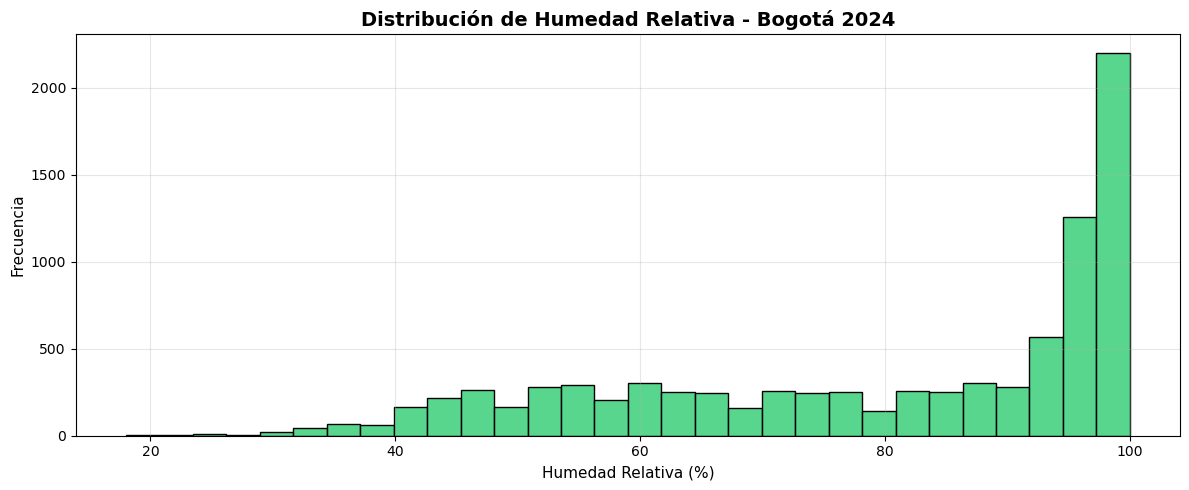

In [7]:
#Celda - 7 grafica 3: Dsitribucion de humedad relativa
fig, ax = plt.subplots(figsize=(12,5))

sns.histplot(df["relativehumidity_2m"], bins=30,
             color = "#2ECC71", alpha=0.8, ax=ax)

ax.set_title("Distribución de Humedad Relativa - Bogotá 2024", fontsize=14, fontweight="bold")
ax.set_xlabel("Humedad Relativa (%)", fontsize=11)
ax.set_ylabel("Frecuencia", fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Figura guardada correctamente


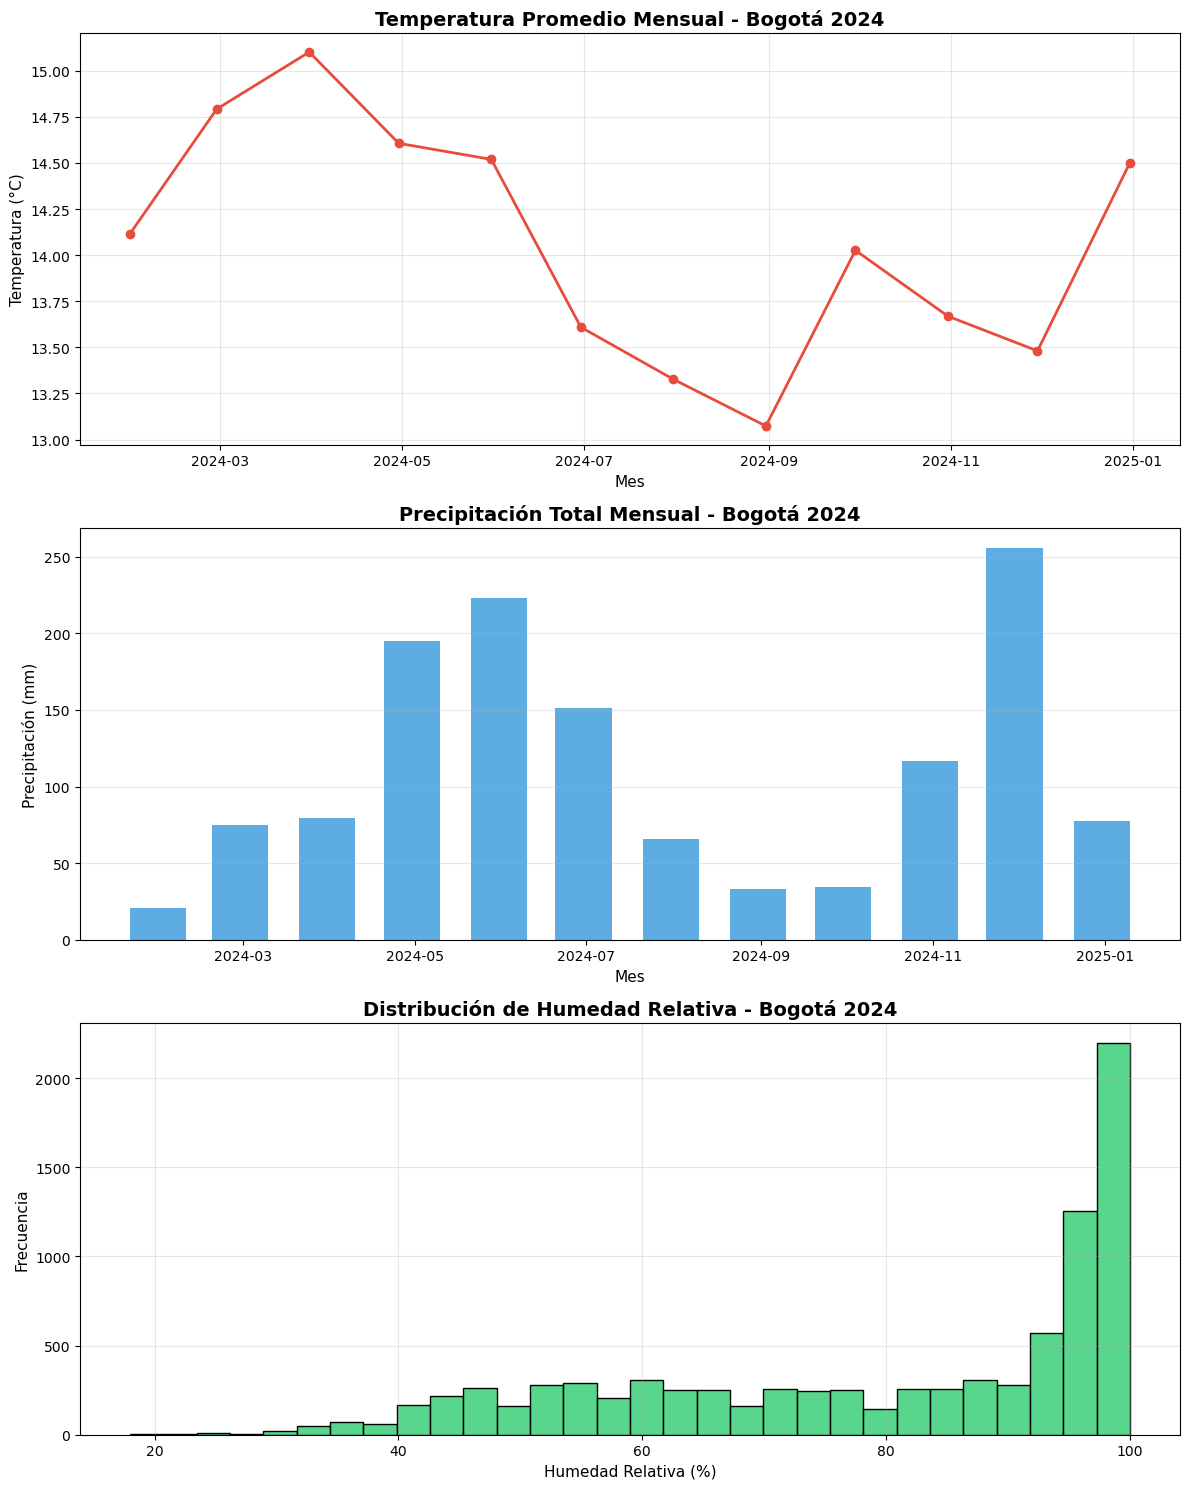

In [14]:
#Celda 8 - Guardar las tres visualizaciones en una sola figura
fig, axes = plt.subplots(3, 1, figsize=(12,15))

#Grafica 1 - Temperatura

axes[0].plot(df_mensual.index, df_mensual["temperature_2m"],
        marker="o", color="#E74C3C", linewidth=2)

axes[0].set_title("Temperatura Promedio Mensual - Bogotá 2024", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Mes", fontsize=11)
axes[0].set_ylabel("Temperatura (°C)", fontsize=11)
axes[0].grid(True, alpha=0.3)

#Grafica 2 - Precipitacion
axes[1].bar(df_mensual.index, df_mensual["precipitation"],
            width=20, color="#3498DB", alpha=0.8)
axes[1].set_title("Precipitación Total Mensual - Bogotá 2024", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Mes", fontsize=11)
axes[1].set_ylabel("Precipitación (mm)", fontsize=11)
axes[1].grid(True, alpha=0.3, axis="y")

#Grafica 3 - Humedad

sns.histplot(df["relativehumidity_2m"], bins=30,
             color = "#2ECC71", alpha=0.8, ax=axes[2])

axes[2].set_title("Distribución de Humedad Relativa - Bogotá 2024", fontsize=14, fontweight="bold")
axes[2].set_xlabel("Humedad Relativa (%)", fontsize=11)
axes[2].set_ylabel("Frecuencia", fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()

#Guardar la figura

ruta_figura = os.path.join("..", "data", "processed", "visualizaciones_clima_bogota_2024.png")
plt.savefig(ruta_figura, dpi=150, bbox_inches="tight")
print("Figura guardada correctamente")
plt.show()